##Step 2: Data Collection

###Import Necessary Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import keras
from keras.models import Sequential,load_model
from keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,confusion_matrix,roc_curve,roc_auc_score
import warnings
warnings.filterwarnings('ignore')


###Load Dataset

In [ ]:
diabetes_data = pd.read_csv('diabetes.csv')
diabetes_data


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


##Step 3: Data Understanding

###Perform Initial Investigation

In [ ]:
diabetes_data.shape

(768, 9)

In [ ]:
diabetes_data.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
diabetes_data.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [ ]:
diabetes_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


##Step 4: Data Preparation

In [ ]:
X = diabetes_data.drop(columns='Outcome')
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [ ]:
y = diabetes_data['Outcome']
y

,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


##Step 5: Model Building

###Train Test Split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X, y,test_size=0.2,random_state=13,shuffle=True,stratify=y,)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = Sequential([
    keras.layers.Input(shape=(8,)),
    Dense(units=12,kernel_initializer='uniform',activation='relu'),
    Dense(units=8,kernel_initializer='uniform',activation='relu'),
    Dense(units=4,kernel_initializer='uniform',activation='relu'),
    Dense(units=1,kernel_initializer='uniform',activation='sigmoid')
])

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

##Step 6: Model Training || Step 7: Model Testing

In [ ]:
model.fit(X_train,y_train,batch_size=10,epochs=67,validation_split=0.2)

Epoch 1/67
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8513 - loss: 0.3709 - val_accuracy: 0.7154 - val_loss: 0.5643
Epoch 2/67
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8513 - loss: 0.3712 - val_accuracy: 0.7236 - val_loss: 0.5555
Epoch 3/67
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8493 - loss: 0.3704 - val_accuracy: 0.7317 - val_loss: 0.5596
Epoch 4/67
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8452 - loss: 0.3735 - val_accuracy: 0.7317 - val_loss: 0.5663
Epoch 5/67
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8513 - loss: 0.3726 - val_accuracy: 0.7154 - val_loss: 0.5676
Epoch 6/67
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8554 - loss: 0.3714 - val_accuracy: 0.7236 - val_loss: 0.5649
Epoch 7/67
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8493 - loss: 0.3698 - val_accuracy: 0.7236 - val_loss: 0.5686
Epoch 8/67
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8534 - loss: 0.3717 - val_accuracy: 0.7317 - val_loss

### Model Prediction

In [ ]:
y_pred = model.predict(X_test)
y_pred
y_pred = (y_pred > 0.5).astype(int)
y_pred

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


array([[0],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
    

##Step 8: Model Evaluation

In [ ]:
print('confusion_matrix:\n',confusion_matrix(y_test,y_pred))
print('\n',classification_report(y_test,y_pred))

confusion_matrix:
 [[75 25]
 [18 36]]

               precision    recall  f1-score   support

           0       0.81      0.75      0.78       100
           1       0.59      0.67      0.63        54

    accuracy                           0.72       154
   macro avg       0.70      0.71      0.70       154
weighted avg       0.73      0.72      0.72       154



###ROC Curve

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
ROC_AUC_SCORE: 0.7692592592592593


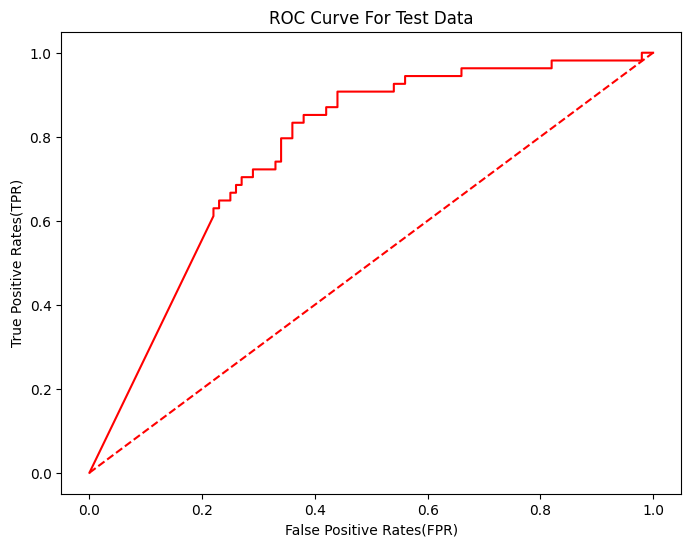

In [ ]:
y_prob = model.predict(X_test)
fpr,tpr,threshold = roc_curve(y_test,y_prob)
print('ROC_AUC_SCORE:',roc_auc_score(y_test,y_prob))
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='red')
plt.plot([0,1],[0,1],linestyle='--',color='red')
plt.title('ROC Curve For Test Data')
plt.xlabel('False Positive Rates(FPR)')
plt.ylabel('True Positive Rates(TPR)')
plt.show()

##Step 9: Model Deployment

In [ ]:
model.save('diabetes_intelligence.h5')

In [ ]:
diabetes_intelligence =  load_model('diabetes_intelligence.h5')

###Predicting the diabetes with new data

In [ ]:
new_data = np.array([[1,92,72,22,85,23.8,0.21,27]])
new_data = scaler.transform(new_data)
predicted_prob = diabetes_intelligence.predict(new_data)
print('Probability:',predicted_prob)
predicted = (predicted_prob > 0.50).astype(int)
print('Diabetes Prediction:',predicted[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Probability: [[0.00829607]]
Diabetes Prediction: 0
